# 01. Data Audit and Exploratory Data Analysis (EDA)
**CSE437 Final Project: Disparity and Error Analysis in Linear Income Classification**  
*Texas 2023 ACS 1-Year PUMS Microdata*

---

### Purpose
1. **Raw Data Ingestion & Schema Audit:** Ingest person-level microdata (`psam_p48.csv`), audit memory usage, and verify the presence of required demographic and labor attributes[cite: 7].
2. **Data Quality & Missing Value Inspection:** Evaluate null values, impossible entries, and non-working populations[cite: 7].
3. **Cohort Filtering:** Restrict records to civilian workers actively employed full-time (`ESR == 1`, `WKHP >= 35`, `PERNP > 0`)[cite: 6].
4. **Target Construction:** Empirically compute the 75th percentile earnings threshold ($90,000.00) and construct the binary target `HIGH_EARNER`[cite: 6].

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set display options for clean terminal/notebook tables
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 1000)

# Portable path resolution (handles execution from either repo root or notebooks/ folder)
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = REPO_ROOT / "data" / "raw" / "psam_p48.csv"

# Fallback: check current directory if raw directory does not contain psam_p48.csv
if not RAW_DATA_PATH.exists():
    if (Path.cwd() / "psam_p48.csv").exists():
        RAW_DATA_PATH = Path.cwd() / "psam_p48.csv"
    elif (REPO_ROOT / "psam_p48.csv").exists():
        RAW_DATA_PATH = REPO_ROOT / "psam_p48.csv"
    else:
        raise FileNotFoundError(
            f"Could not locate 'psam_p48.csv'. Looked in:\n"
            f" - {RAW_DATA_PATH}\n"
            f" - {Path.cwd() / 'psam_p48.csv'}\n"
            "Please ensure raw microdata is placed in data/raw/ or downloaded via python src/download_data.py"
        )

print(f"[STATUS] Project root: {REPO_ROOT}")
print(f"[STATUS] Ingesting raw microdata from: {RAW_DATA_PATH.resolve()}")

[STATUS] Project root: c:\Users\Sandip Kumar Paul\Downloads\csv_ptx
[STATUS] Ingesting raw microdata from: C:\Users\Sandip Kumar Paul\Downloads\csv_ptx\psam_p48.csv


## 1. Raw Dataset Ingestion & Schema Audit
We first inspect the dimensions, column presence, and memory footprint of the raw Census microdata file[cite: 7].

In [2]:
# Candidate attributes required for downstream modeling and exploratory auditing[cite: 6]
core_attributes = [
    "PERNP",  # Total person's annual earnings (target foundation)[cite: 6]
    "WKHP",  # Usual hours worked per week past 12 months (full-time filter)[cite: 6, 7]
    "ESR",  # Employment status recode (civilian labor filter)[cite: 6, 7]
    "AGEP",  # Reported person age (experience / life cohort control)[cite: 6, 7]
    "SEX",  # Demographic sex identifier (focal variable for RQ1)[cite: 6, 7]
    "SCHL",  # Educational attainment level (credential tier analysis for RQ1)[cite: 6, 7]
    "MAR",  # Marital status control[cite: 6]
    "COW",  # Class of worker / employment sector (focal variable for RQ2)[cite: 6, 7]
    "OCCP",  # 4-digit SOC occupation code[cite: 6, 7]
    "WKWN",  # Weeks worked past 12 months (evaluated for parsimony)[cite: 6]
]

# Read first 5 rows to verify schema without memory overhead
preview_df = pd.read_csv(RAW_DATA_PATH, nrows=5)
print("=" * 65)
print("RAW CENSUS MICRODATA SCHEMA AUDIT")
print("=" * 65)
print(f"Total attributes present in raw file: {len(preview_df.columns)}")

missing_cols = [c for c in core_attributes if c not in preview_df.columns]
if missing_cols:
    raise KeyError(f"Missing required Census columns: {missing_cols}")
print(f"[SUCCESS] All {len(core_attributes)} candidate attributes verified in dataset.")

# Ingest full candidate matrix[cite: 6]
print("\nIngesting analytical columns...")
df_raw = pd.read_csv(RAW_DATA_PATH, usecols=core_attributes)

raw_rows, raw_cols = df_raw.shape
ram_usage_mb = df_raw.memory_usage(deep=True).sum() / (1024**2)
print(f"Total Observations Ingested: {raw_rows:,}")
print(f"Candidate Features Retained: {raw_cols}")
print(f"Memory Footprint in RAM:     {ram_usage_mb:.2f} MB")
print("=" * 65)
df_raw.head()

RAW CENSUS MICRODATA SCHEMA AUDIT
Total attributes present in raw file: 287
[SUCCESS] All 10 candidate attributes verified in dataset.

Ingesting analytical columns...
Total Observations Ingested: 301,984
Candidate Features Retained: 10
Memory Footprint in RAM:     23.04 MB


,AGEP,COW,MAR,SCHL,SEX,WKHP,WKWN,ESR,OCCP,PERNP
0,20,1.0,5,16.0,1,40.0,15.0,6.0,1555.0,12000.0
1,28,1.0,5,16.0,1,60.0,52.0,1.0,8030.0,8000.0
2,22,1.0,5,19.0,1,40.0,12.0,6.0,9130.0,2700.0
3,33,6.0,4,14.0,2,30.0,13.0,1.0,4230.0,3600.0
4,66,NaN,5,16.0,1,NaN,NaN,6.0,NaN,0.0


## 2. Missing Values and Data Quality Audit
Prior to cohort filtering, we evaluate missing values, structural non-response mechanisms, and unadjusted earnings distributions across the entire Texas population.

In [3]:
print("=" * 65)
print("DATA QUALITY & MISSING VALUES PER COLUMN")
print("=" * 65)

quality_summary = pd.DataFrame(
    {
        "Data Type": df_raw.dtypes,
        "Missing Values (Count)": df_raw.isnull().sum(),
        "Missing Proportion (%)": (df_raw.isnull().sum() / len(df_raw)) * 100,
        "Unique Values": df_raw.nunique(),
    }
)
print(quality_summary)
print("-" * 65)
print("Key Observations:")
print(
    f"- Missing PERNP (earnings): {df_raw['PERNP'].isnull().sum():,} rows "
    f"({(df_raw['PERNP'].isnull().sum() / len(df_raw)) * 100:.2f}%) correspond to non-workers/children (Missing by Design)."
)
print(
    f"- Missing WKHP (hours):    {df_raw['WKHP'].isnull().sum():,} rows "
    f"({(df_raw['WKHP'].isnull().sum() / len(df_raw)) * 100:.2f}%) correspond to non-active labor."
)

DATA QUALITY & MISSING VALUES PER COLUMN
      Data Type  Missing Values (Count)  Missing Proportion (%)  Unique Values
AGEP      int64                       0                0.000000             90
COW     float64                  122864               40.685599              9
MAR       int64                       0                0.000000              5
SCHL    float64                    8744                2.895518             24
SEX       int64                       0                0.000000              2
WKHP    float64                  146742               48.592641             96
WKWN    float64                  146742               48.592641             52
ESR     float64                   55043               18.227125              6
OCCP    float64                  122864               40.685599            530
PERNP   float64                   55043               18.227125           1730
-----------------------------------------------------------------
Key Observations:
- Miss

## 3. Cohort Filtering: Active Civilian Full-Time Workforce
We restrict the study cohort to active, full-time civilian workers[cite: 6]:
1. `ESR == 1`: Civilian employed, actively at work (excludes unemployed, absent, and armed forces)[cite: 6].
2. `WKHP >= 35`: Bureau of Labor Statistics standard threshold for full-time labor[cite: 6].
3. `PERNP > 0`: Positive wage earnings (excludes negative business loss or unpaid entries)[cite: 6].

In [4]:
# Apply population filtering criteria[cite: 6]
df_filtered = df_raw[
    (df_raw["ESR"] == 1) & (df_raw["WKHP"] >= 35) & (df_raw["PERNP"] > 0)
].copy()

filtered_rows, _ = df_filtered.shape
reduction_pct = ((raw_rows - filtered_rows) / raw_rows) * 100

print("=" * 65)
print("METHODOLOGICAL COHORT FILTERING")
print("=" * 65)
print(f"Raw Survey Observations:           {raw_rows:,}")
print(f"Filtered Full-Time Labor Universe: {filtered_rows:,}")
print(
    f"Filtered Out (Non-Workers/Part-Time): {raw_rows - filtered_rows:,} ({reduction_pct:.2f}%)"
)
print("=" * 65)

METHODOLOGICAL COHORT FILTERING
Raw Survey Observations:           301,984
Filtered Full-Time Labor Universe: 112,319
Filtered Out (Non-Workers/Part-Time): 189,665 (62.81%)


## 4. Target Variable Construction: High-Earner Cutoff ($90,000)
We determine the empirical 75th percentile cutoff on the filtered full-time workforce to create the binary classification target `HIGH_EARNER`[cite: 6].

In [5]:
# Calculate empirical earnings distribution metrics[cite: 6]
p25 = df_filtered["PERNP"].quantile(0.25)
median_earnings = df_filtered["PERNP"].median()
p75_threshold = df_filtered["PERNP"].quantile(0.75)
p90 = df_filtered["PERNP"].quantile(0.90)

print("=" * 65)
print("EARNINGS DISTRIBUTION (FULL-TIME CIVILIAN WORKERS)")
print("=" * 65)
print(f"Minimum Earnings:           ${df_filtered['PERNP'].min():>12,.2f}")
print(f"25th Percentile (P25):      ${p25:>12,.2f}")
print(f"Median Earnings (P50):      ${median_earnings:>12,.2f}")
print(f"75th Percentile Cutoff (P75): ${p75_threshold:>12,.2f}")
print(f"90th Percentile (P90):      ${p90:>12,.2f}")
print(f"Maximum Earnings:           ${df_filtered['PERNP'].max():>12,.2f}")
print("-" * 65)

# Derive binary target variable[cite: 6]
df_filtered["HIGH_EARNER"] = (df_filtered["PERNP"] >= p75_threshold).astype(
    int
)

# Inspect target class balance[cite: 6]
class_counts = df_filtered["HIGH_EARNER"].value_counts()
class_props = df_filtered["HIGH_EARNER"].value_counts(normalize=True) * 100

print("Target Class Distribution (HIGH_EARNER):")
print(
    f"  Class 0 (Standard Earners < $90,000): {class_counts[0]:,} ({class_props[0]:.2f}%)"
)
print(
    f"  Class 1 (High Earners     >= $90,000): {class_counts[1]:,} ({class_props[1]:.2f}%)"
)
print("=" * 65)

EARNINGS DISTRIBUTION (FULL-TIME CIVILIAN WORKERS)
Minimum Earnings:           $        1.00
25th Percentile (P25):      $   33,000.00
Median Earnings (P50):      $   55,000.00
75th Percentile Cutoff (P75): $   90,000.00
90th Percentile (P90):      $  150,000.00
Maximum Earnings:           $  985,000.00
-----------------------------------------------------------------
Target Class Distribution (HIGH_EARNER):
  Class 0 (Standard Earners < $90,000): 82,875 (73.79%)
  Class 1 (High Earners     >= $90,000): 29,444 (26.21%)


## 5. Exploratory Data Visualization
Visualizing the continuous earnings distribution, logarithmic transformation, and class balance across gender cohorts.

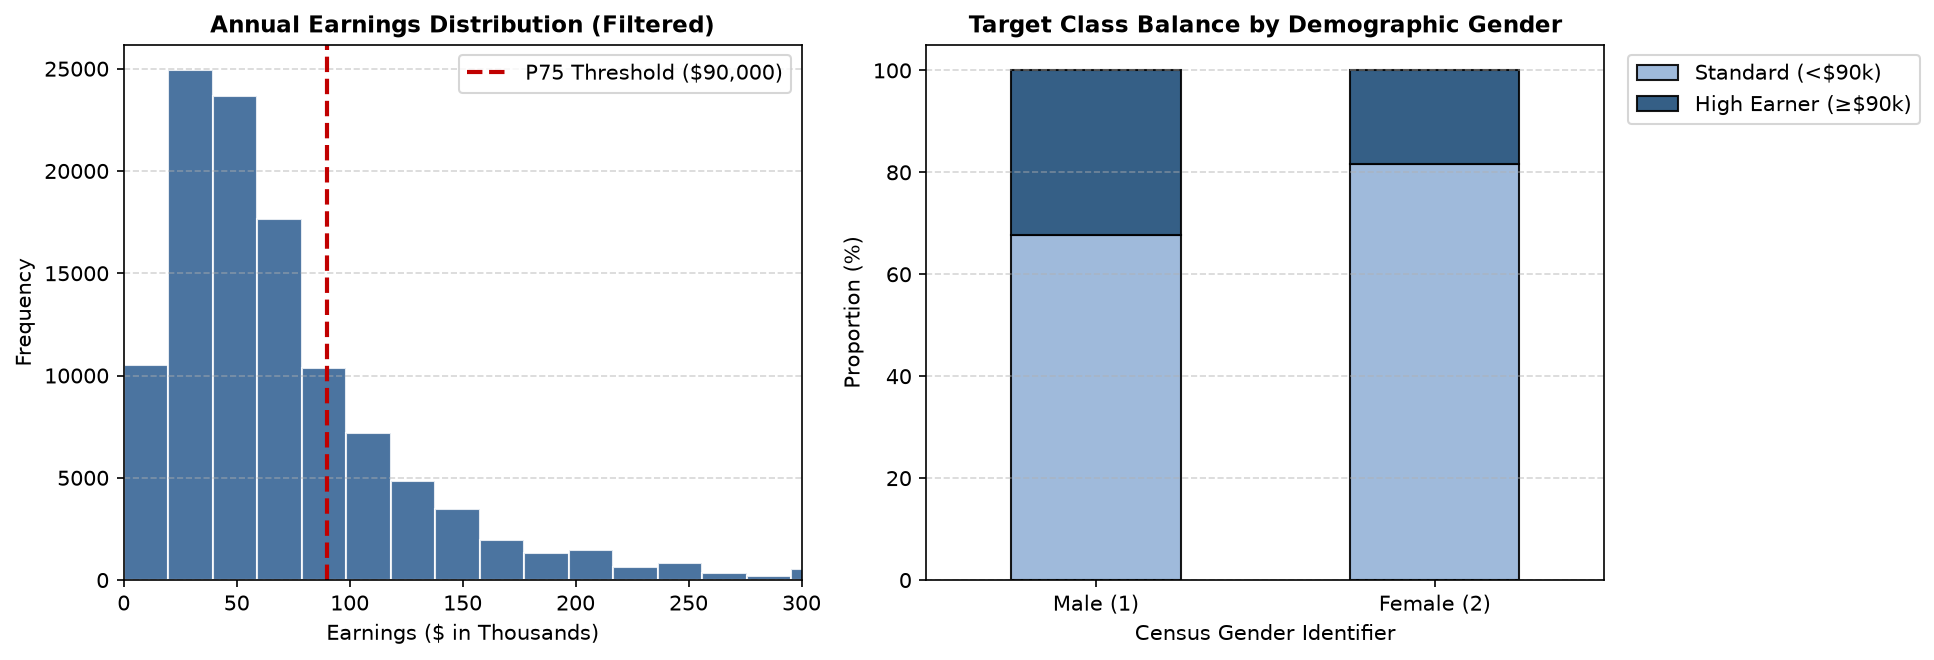

[SUCCESS] Notebook 01 EDA and Data Audit successfully executed.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)

# Earnings Distribution
axes[0].hist(
    df_filtered["PERNP"] / 1000,
    bins=50,
    color="#2b5c8f",
    edgecolor="white",
    alpha=0.85,
)
axes[0].axvline(
    p75_threshold / 1000,
    color="#c00000",
    linestyle="--",
    linewidth=2,
    label=f"P75 Threshold (${p75_threshold:,.0f})",
)
axes[0].set_title(
    "Annual Earnings Distribution (Filtered)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Earnings ($ in Thousands)", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].set_xlim(0, 300)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Target Balance by Gender (1 = Male, 2 = Female in raw Census codes)
sex_high_earner = (
    df_filtered.groupby("SEX")["HIGH_EARNER"].value_counts(normalize=True).unstack()
    * 100
)
sex_high_earner.index = ["Male (1)", "Female (2)"]
sex_high_earner.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#95b3d7", "#1f4e79"],
    edgecolor="black",
    alpha=0.9,
)
axes[1].set_title(
    "Target Class Balance by Demographic Gender",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Census Gender Identifier", fontsize=10)
axes[1].set_ylabel("Proportion (%)", fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(
    ["Standard (<$90k)", "High Earner (≥$90k)"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("[SUCCESS] Notebook 01 EDA and Data Audit successfully executed.")